# Data Visualization and Mapping

In this session, we will explore some advance graphing and data display options, largely using `ggplot2` and related packages. There is so much here; we could easily spend several sessions covering just this material. 

The data we will use comes from U.S. Census Bureau, and we'll use the **{censusapi}** and **{tidycensus}** packages to pull the data. 

First, let's load the packages we'll be using in the session.

In [47]:
pacman::p_load(censusapi, tidyverse, scales, tidycensus, ggtext, ggpubr, paletteer, RColorBrewer, ggnewscale)

In [48]:
apiout <- listCensusApis() # to view find the name of the api

# place your API call to the Census
cog <- getCensus(
  name = "timeseries/govsstatefin",   # data series, api name
  region = "state",                   # level of data
  vars = c("YEAR", "NAME", "AGG_DESC",  # variables requested
    "AGG_DESC_LABEL", "GOVTYPE", 
    "GOVTYPE_LABEL", "AMOUNT")
)

Using the Census of Governments' State Gov Finances data, we can analyze how much of New Jersey's tax revenue comes from various sources. 

In [49]:
cognj <- cog |> 
  filter(GOVTYPE==2 & state == "34" & YEAR == 2024) |>
  filter(AGG_DESC %in% c("SF0038", "SF0063", "SF0053", "SF0037", "SF0051", "SF0052")) |>
  mutate(taxlabel = case_when(
    AGG_DESC == "SF0037" ~ "Property",
    AGG_DESC == "SF0038" ~ "Sales",
    AGG_DESC == "SF0051" ~ "Income - Ind",
    AGG_DESC == "SF0052" ~ "Income - Corp",
    AGG_DESC == "SF0053" ~ "License",
    AGG_DESC == "SF0063" ~ "Other"
    )
  )

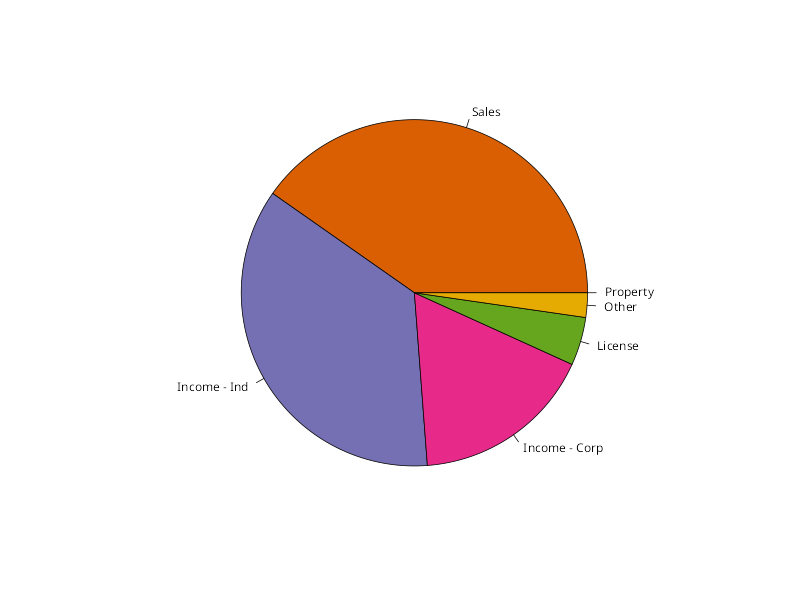

In [50]:
pal <- brewer.pal(6, "Dark2")

pie(cognj$AMOUNT,
     labels = cognj$taxlabel,
     col = pal)

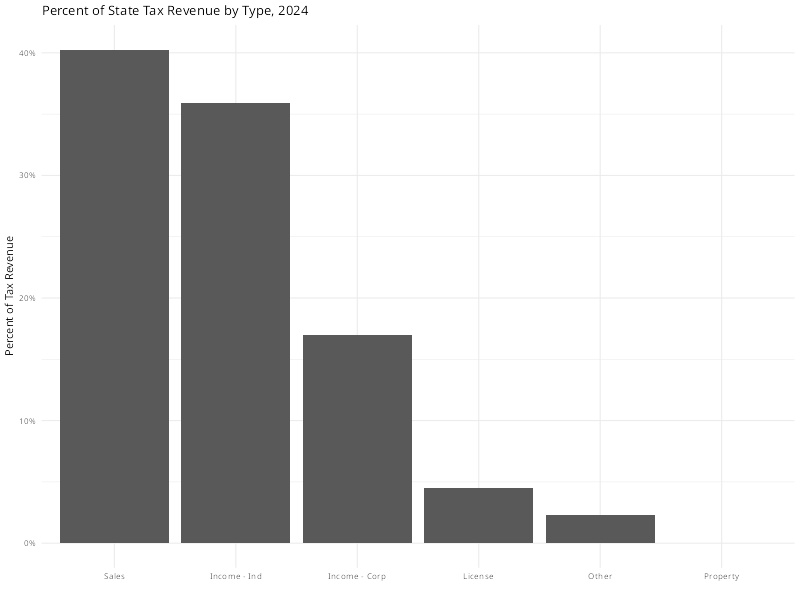

In [51]:
ggplot(cognj, mapping = aes(y = AMOUNT/ sum(AMOUNT), x = fct_reorder(taxlabel, desc(AMOUNT)))) +
  geom_col() +
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Percent of State Tax Revenue by Type, 2024",
    x = "",
    y = "Percent of Tax Revenue") +
  theme_minimal() 

In [52]:
cogmulti <- cog |> 
  filter(GOVTYPE==2 & (state == "34" | state == "42" | state == "10" | state == "36")  & YEAR == 2024) |>
  filter(AGG_DESC %in% c("SF0038", "SF0063", "SF0053", "SF0037", "SF0051", "SF0052")) |>
  arrange(AGG_DESC) |>
  mutate(taxlabel = case_when(
    AGG_DESC == "SF0037" ~ "Property",
    AGG_DESC == "SF0038" ~ "Sales",
    AGG_DESC == "SF0051" ~ "Income - Ind",
    AGG_DESC == "SF0052" ~ "Income - Corp",
    AGG_DESC == "SF0053" ~ "License",
    AGG_DESC == "SF0063" ~ "Other"
    )
  )

cogmulti <- cogmulti |>
  group_by(state) |>
  mutate(st.amount = sum(AMOUNT)
)

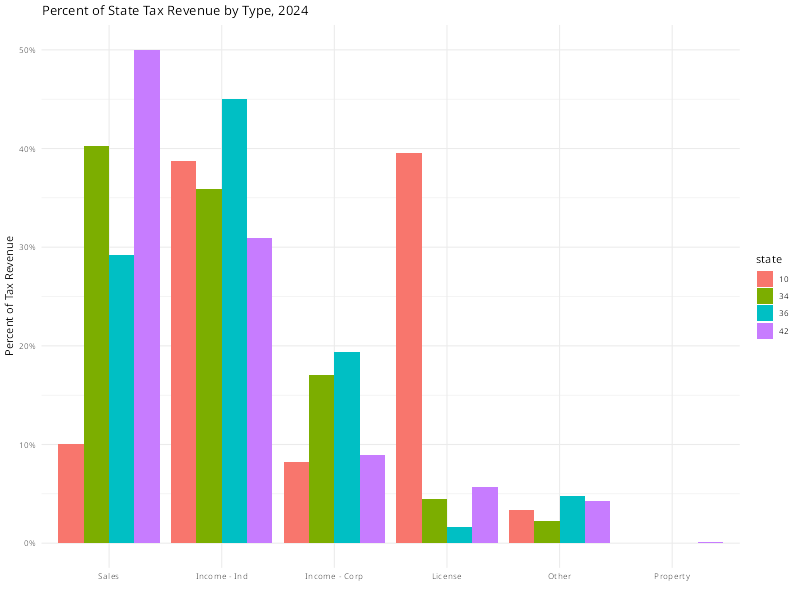

In [53]:
ggplot(cogmulti, 
    mapping = aes(y = AMOUNT/ st.amount, 
    x = fct_reorder(taxlabel, desc(AMOUNT)),
    group = state,
    fill = state)) +
  geom_col(position = position_dodge()) +
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Percent of State Tax Revenue by Type, 2024",
    x = "",
    y = "Percent of Tax Revenue") +
  theme_minimal() 

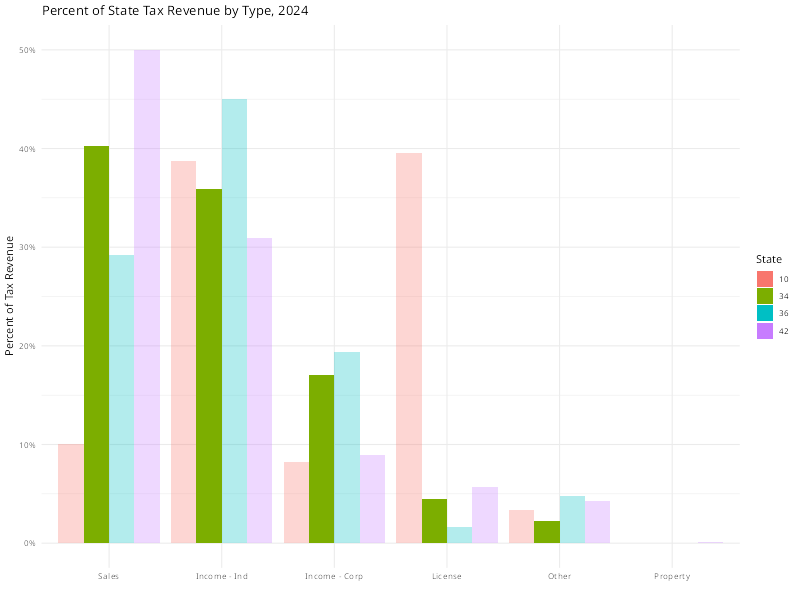

In [54]:
cogmulti$focus <- if_else(cogmulti$state == "34", 1, .3, NA) 

ggplot(cogmulti, 
    mapping = aes(y = AMOUNT/ st.amount, 
    x = fct_reorder(taxlabel, desc(AMOUNT)),
    group = state,
    fill = state)) +
  geom_col(position = position_dodge(), aes(alpha = focus)) +
  scale_y_continuous(labels = scales::percent) +
  scale_alpha_identity() + 
  labs(title = "Percent of State Tax Revenue by Type, 2024",
    x = "",
    y = "Percent of Tax Revenue",
    fill = "State") +
  theme_minimal() 

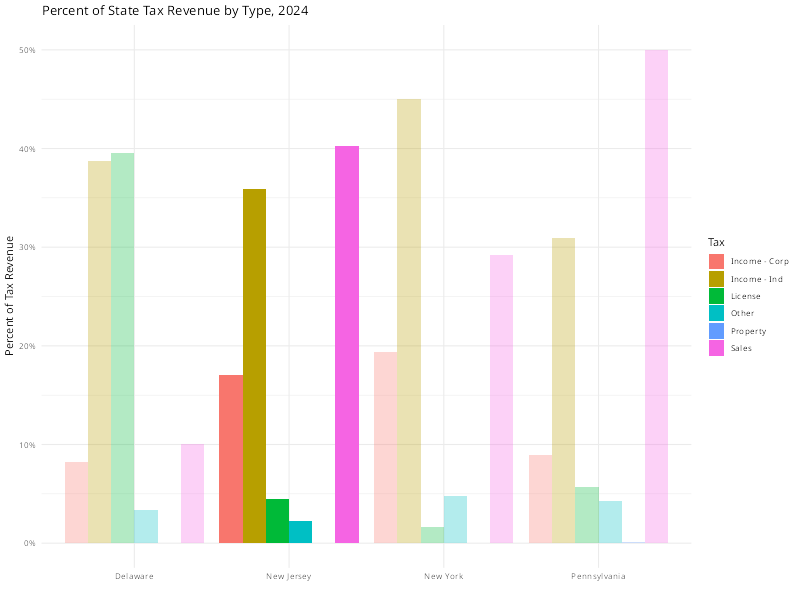

In [55]:
ggplot(cogmulti, 
    mapping = aes(y = AMOUNT/ st.amount, 
    x = state,
    group = taxlabel,
    fill = taxlabel,
    )) +
  geom_col(position = position_dodge(), aes(alpha = focus)) +
  scale_y_continuous(labels = scales::percent) +
  scale_alpha_identity() +
  scale_x_discrete(labels = c("Delaware", "New Jersey", "New York", "Pennsylvania")) +
  labs(title = "Percent of State Tax Revenue by Type, 2024",
    x = "",
    y = "Percent of Tax Revenue",
    fill = "Tax") +
  theme_minimal() 

In [56]:
saipe_nj <- getCensus(
  name = "timeseries/poverty/saipe",
  region = "state:34",
  vars = c("YEAR", "SAEPOVRT0_17_PT", "SAEPOVRTALL_PT")
)

for(st in c("10", "34", "36", "42")){
  if(st == "10"){
    saipe <- getCensus(
      name = "timeseries/poverty/saipe",
      region = paste0("state:", st),
      vars = c("YEAR", "SAEPOVRT0_17_PT", "SAEPOVRTALL_PT")
    )
    saipe.all <- saipe
  } else {
    saipe <- getCensus(
      name = "timeseries/poverty/saipe",
      region = paste0("state:", st),
      vars = c("YEAR", "SAEPOVRT0_17_PT", "SAEPOVRTALL_PT")
    )
    saipe.all <- bind_rows(saipe.all, saipe)
  }
}

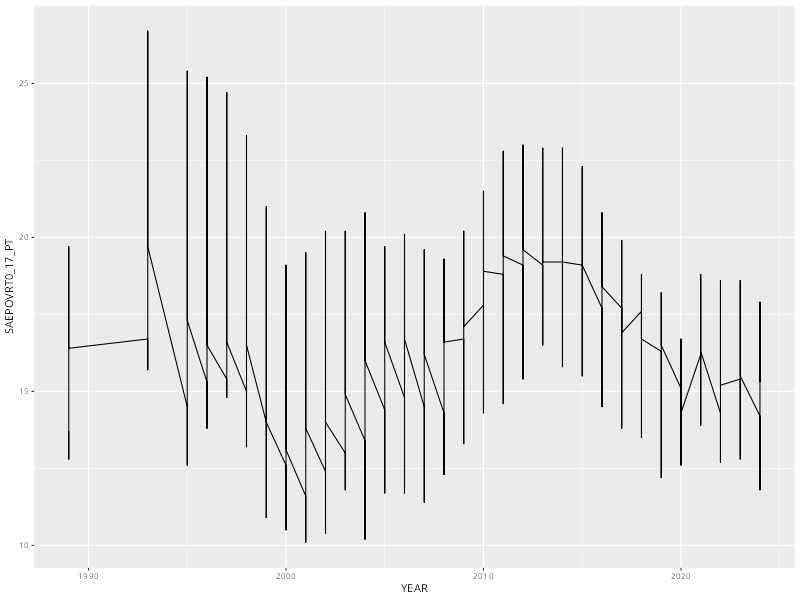

In [57]:
ggplot(
  data = saipe.all,
  mapping = aes(x = YEAR, y = SAEPOVRT0_17_PT)
) +
  geom_line()

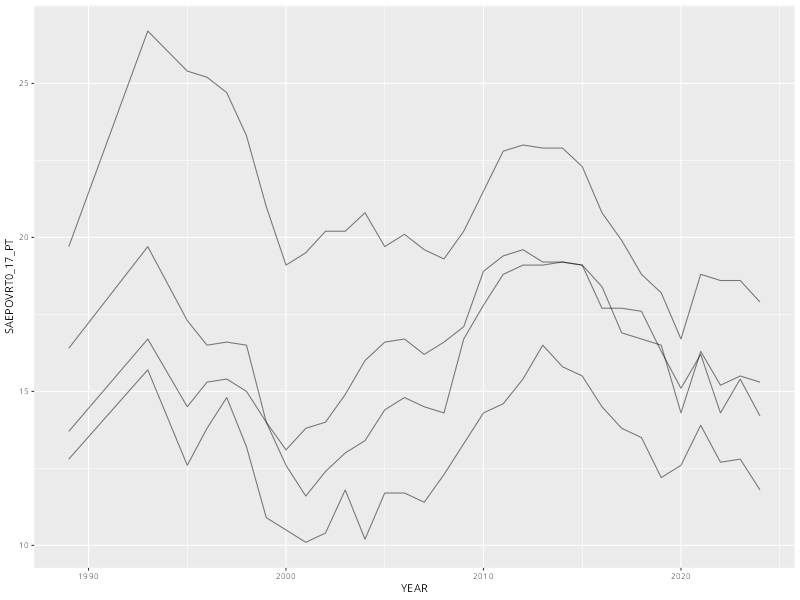

In [58]:
p1 <- ggplot(
  data = saipe.all,
  mapping = aes(x = YEAR, y = SAEPOVRT0_17_PT, group = state)
) +
  geom_line(alpha = .5)
p1

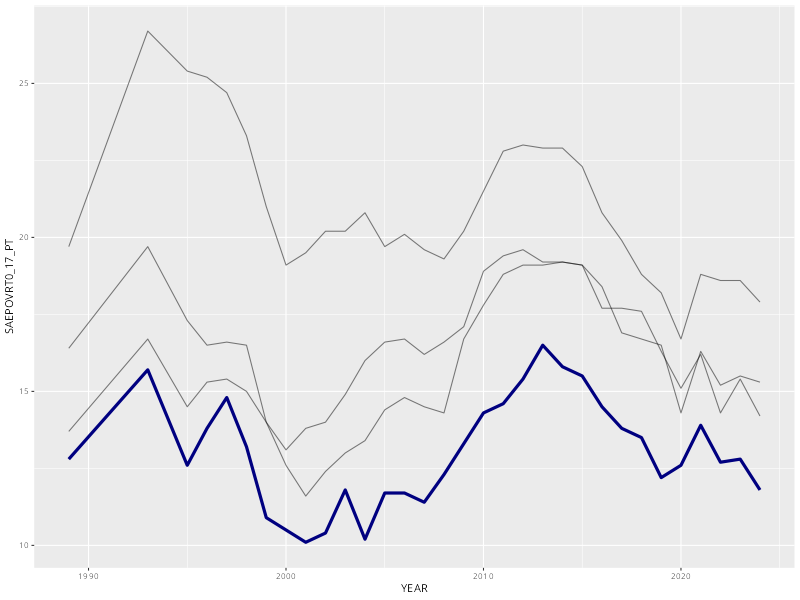

Warning messages:
1: Removed 28 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 7 rows containing missing values or values outside the scale range (`geom_line()`). 
3: Removed 28 rows containing missing values or values outside the scale range (`geom_point()`). 
4: Removed 7 rows containing missing values or values outside the scale range (`geom_point()`). 


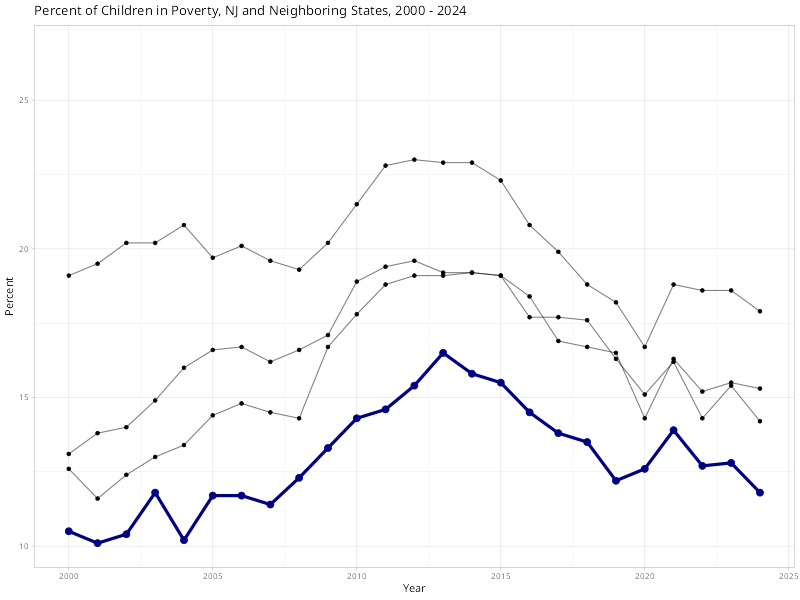

In [59]:

p1 +
  geom_line(data = saipe.all |> filter(state == "34"), color = "navy", linewidth = 1.5)

p1 + 
  geom_line(data = saipe.all |> filter(state == "34"), color = "navy", linewidth = 1.5) +
  geom_point() +
  geom_point(data = saipe.all |> filter(state == "34"), color = "navy", size = 3) +
  xlim(2000, 2024) +
  labs(
    title = "Percent of Children in Poverty, NJ and Neighboring States, 2000 - 2024",
    y = "Percent",
    x = "Year"
  ) +
  theme_light()

`tidycensus` is, for my money, one of the top R packages. It provides integration with the U.S. Census Bureau's API with access to the decennial census and the American Community Survey, allowing you to download data directly by your geography of interest into R. To do this, you need to know the Census product you want to use, the time, the level (state, county, zip code, etc), and the variables. 

In this example, we will use data from the American Community Survey, the 5-year estimates for 2024, which aggregate ACS data from 2020-2024. ACS data has many advantages over the decennial census data, offering additional questions about income and education that are not asked on the decennial census. The downside, of course, is that the ACS is a survey, and we cannot get reliable estimates of very small units (like blocks) using these data. 

For this activity, let's download data on method of travel to work by NJ county subdivisions. To use `tidycensus`, you first need to know the name of the census variable. You can use the `load_variables()` function to get a table of available variables, with labels, from the dataset. Then, you would need to carefully review the table to find the variables you want to download. Note that often census data comes as counts when we would typically want percentages or proportions. So be sure to collect both the count of the variable of interest (numerator) and the variable that captures the relevant population (denominator).

I recommend reviewing `tidycensus`' [excellent website](https://walker-data.com/tidycensus/index.html) to better understand the core functions.

In [60]:
vars_2024 <- load_variables(year = 2024, dataset = "acs5")

varlist <- c(workers = "B08006_001" ,                     # you can rename the variables from
             drove.alone = "B08006_003" ,                 #   ACS default here
             carpooled = "B08006_004" ,
             pubtransit = "B08006_008" ,
             wfh = "B08006_017",
             medfaminc = "B19113_001")

df <- get_acs(geography = "county subdivision",           # tells the geo level
              state = "NJ",                               # inside of NJ
              variables = varlist,                        # plugs in our stored list
              year = 2024,                                # sets the year of the data
              survey = "acs5",                            # data source
              geometry = TRUE                             # only set to TRUE if mapping 
            )     

Getting data from the 2020-2024 5-year ACS
Using FIPS code '34' for state 'NJ'


These data are organized by county subdivision - variable. We will need to process the data frame before we can graph.

In [61]:
commute <- df |>
  pivot_wider(                         # moves data from rows into columns
    names_from = variable,
    values_from = c(estimate, moe)
  ) |>
  mutate(
    pct.drove = 100*estimate_drove.alone / estimate_workers,
    pct.carpooled = 100*estimate_carpooled/ estimate_workers,
    pct.pubtransit = 100*estimate_pubtransit / estimate_workers,
    pct.wfh = 100*estimate_wfh / estimate_workers,
    county.fips = substr(GEOID, 3, 5),                     # grabs third through fifth characters
    region = case_when(
      county.fips %in% c("037", "041", "031", 
                       "027", "003", "013", 
                       "039", "017") ~ "North Jersey",
      county.fips %in% c("019", "035", "023", 
                       "021", "025") ~ "Central Jersey", 
      TRUE ~ "South Jersey"                              # all unassigned get set to South
    )
  )
  

## Scatterplots and Moving Averages

Scatterplots present the relationship between two variables in a two-dimensional plot space with a dot or point representing an observation's values on both the outcome (y axis) and predictor (x axis). 

Various options exist for summarizing the relationship between your two variables. One excellent option is the *loess* smoother, which is a locally-weighted regression that provides a moving average of Y by values of X. Alternatively, you can plot the OLS regression of your outcome variable on your predictor variable. 

Warning messages:
1: Removed 10 rows containing non-finite outside the scale range (`stat_smooth()`). 
2: The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor? 
3: Removed 10 rows containing missing values or values outside the scale range (`geom_point()`). 


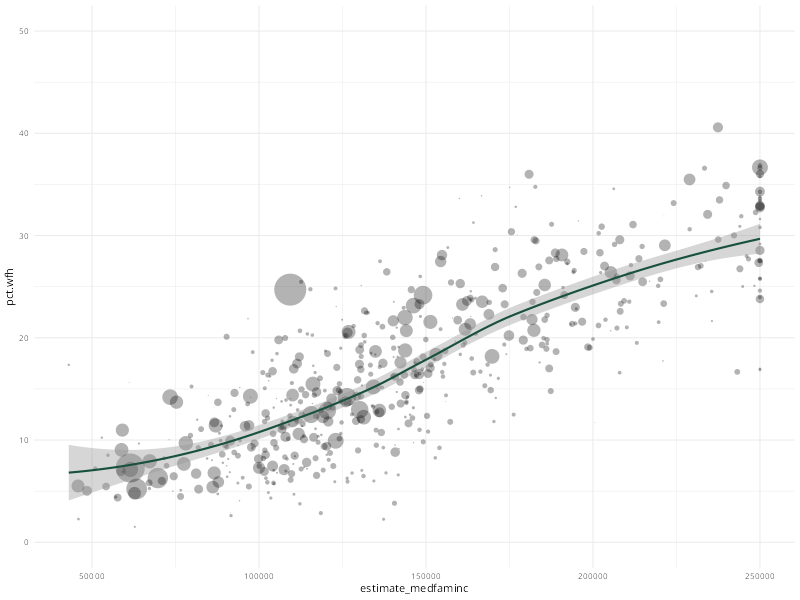

`geom_smooth()` using formula = 'y ~ x'

In [ ]:
wfh <- ggplot(commute, 
        aes(
          x = estimate_medfaminc, 
          y = pct.wfh, 
          size = estimate_workers              # makes point proportional to # of workers
        )
      ) +
      geom_point(alpha = .3, stroke = 0) +     # adds transparency, removes border on points
      geom_smooth(method = "loess", color = "#18523D", ) +
      scale_y_continuous(limits = c(0,50)) +
      scale_size_area(max_size = 15) +         # makes maximum bubbles larger
      theme_minimal() +
      theme(legend.position = "none")          # removes legend
 
wfh

Warning messages:
1: Removed 9 rows containing non-finite outside the scale range (`stat_smooth()`). 
2: The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor? 
3: Removed 9 rows containing missing values or values outside the scale range (`geom_point()`). 


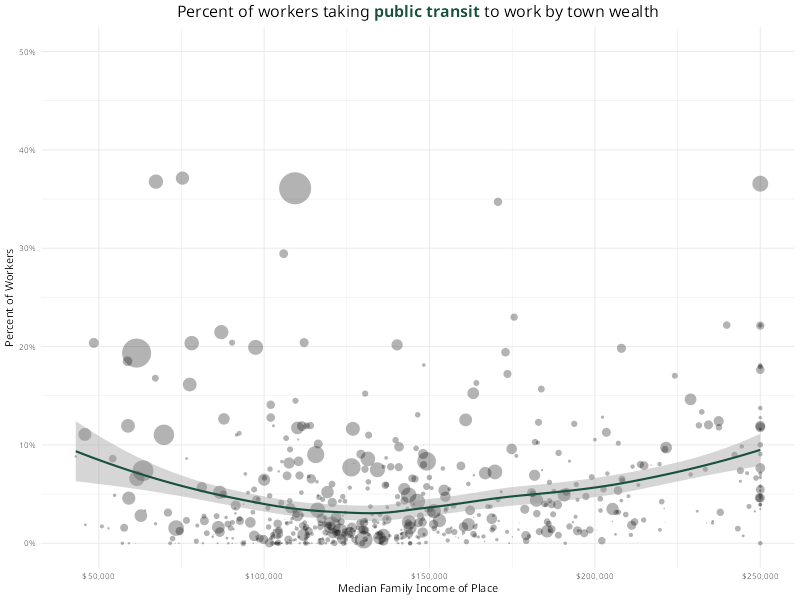

`geom_smooth()` using formula = 'y ~ x'

In [63]:
pt <-ggplot(commute, aes(x = estimate_medfaminc, y = pct.pubtransit, size = estimate_workers)) +
  geom_point(alpha = .3, stroke = 0) +
  geom_smooth(method = "loess", color = "#18523D", ) +
  scale_size_area(max_size = 15) +
  scale_y_continuous(
    limits = c(0, 50),
    labels = label_percent(scale = 1)
  ) +
  scale_x_continuous(
    labels = label_currency(big.mark = ",")
  ) +
  theme_minimal() +
     theme(legend.position = "none",
     plot.title = element_markdown(size = 16, hjust = 0.5)
    ) + 
        labs(
          title = "Percent of workers taking <span style='color:#18523D'>**public transit**</span> to work by town wealth",
          x = "Median Family Income of Place",
          y = "Percent of Workers")

pt

Let's make one more cut of this analysis. Do these relationships change by region of New Jersey?

Warning messages:
1: Removed 10 rows containing non-finite outside the scale range (`stat_smooth()`). 
2: The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor? 
3: The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor? 
4: The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor? 
5: Removed 10 rows containing missing values or values outside the scale range (`geom_p

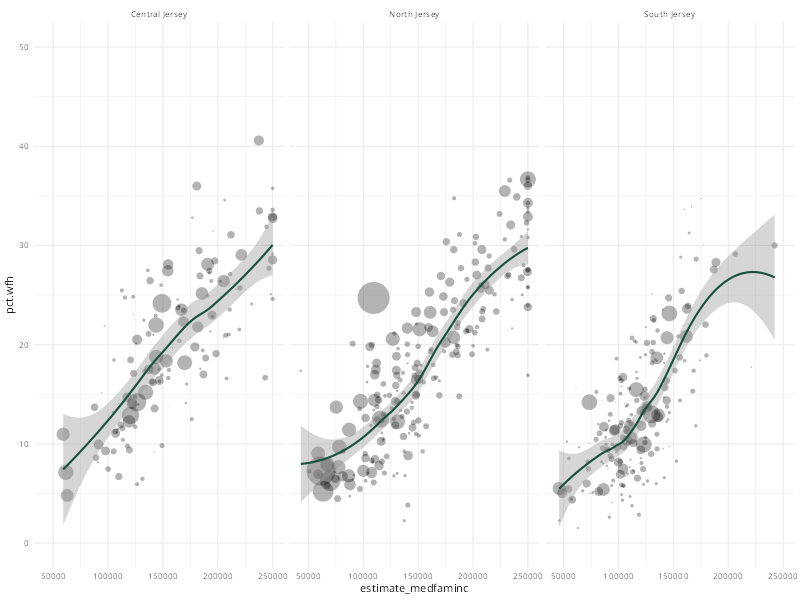

`geom_smooth()` using formula = 'y ~ x'

In [64]:
wfh + facet_grid(~region)

Warning messages:
1: Removed 9 rows containing non-finite outside the scale range (`stat_smooth()`). 
2: The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor? 
3: The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor? 
4: The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor? 
5: Removed 9 rows containing missing values or values outside the scale range (`geom_poi

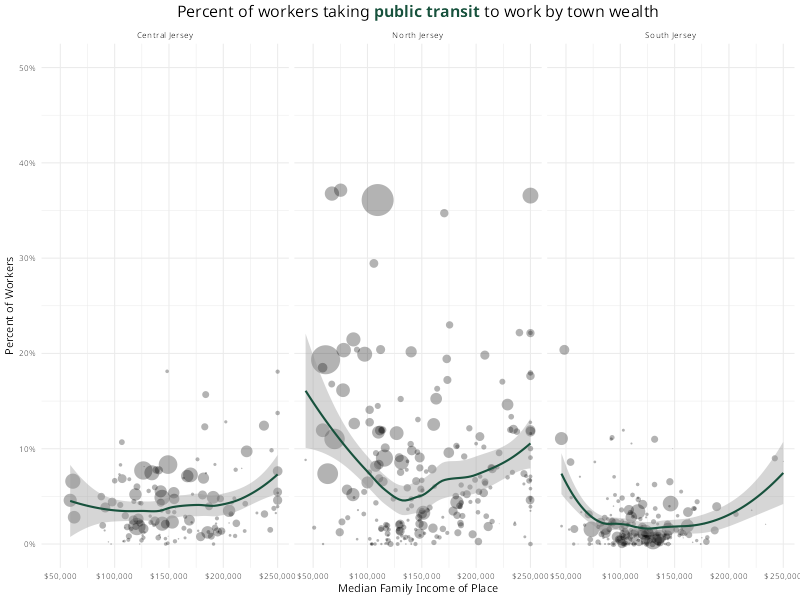

`geom_smooth()` using formula = 'y ~ x'

In [65]:
pt + facet_grid(~region)

## Mapping

R is increasingly becoming a full-featured GIS. Spatial data can be processed in R using **{sf}**, and chloropleth mapping is possible in `ggplot()` with `geom_sf()`. 

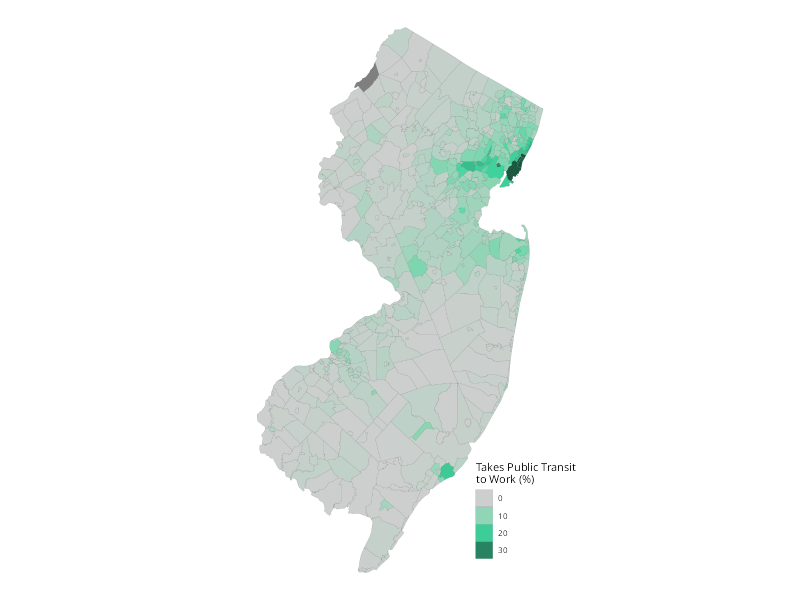

In [66]:
map1 <- ggplot(commute, aes(fill = pct.pubtransit)) +      # identify data and fill variable                          
  geom_sf(linewidth = .05) +                               # identifies a map as the `geom`
  scale_fill_gradientn(colors = c("#cdcfceff","#41d8a1ff", "#18523D")) +
  guides(fill = guide_legend(position = "inside")) +
  labs(fill = "Takes Public Transit\nto Work (%)") +
  theme_void() +
  theme(
    legend.position.inside = c(0.9, 0.15)
  )

map1

This map would probably look better if we added county boundaries. `ggplot()` can only add one fill layer on a graph at a time, so we need to use the **{ggnewscale}** package to let us add another fill layer. This layer will be placed at the end of the `ggplot` code. 

In [67]:
# grab data using tidycensus
county <- get_acs(geography = "county",          
              state = "NJ",
              variables = "B08006_001",          
              year = 2024,                  
              survey = "acs5",             
              geometry = TRUE
            )   

Getting data from the 2020-2024 5-year ACS
Using FIPS code '34' for state 'NJ'


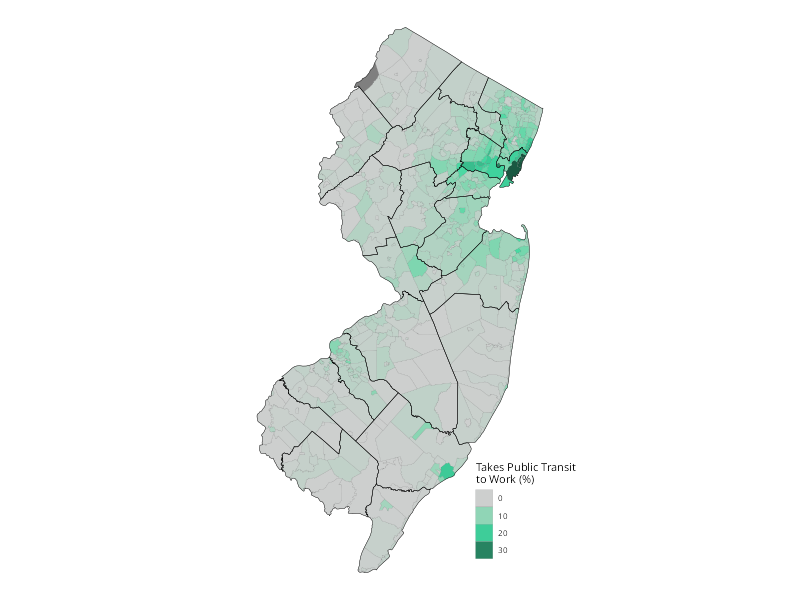

In [68]:
ggplot() +      # leave blank!
  geom_sf(data = commute, # set subdivision data here
    aes(fill = pct.pubtransit), linewidth = .05) +
  scale_fill_gradientn(colors = c("#cdcfceff","#41d8a1ff", "#18523D")) +
  guides(fill = guide_legend(position = "inside")) +
  labs(fill = "Takes Public Transit\nto Work (%)") +
  theme_void() +
  theme(
    legend.position.inside = c(0.9, 0.15)
  ) +
  new_scale_fill() +            # need to place the new layers at the end 
  geom_sf(data = county,       # county data here    
     color = "black",
     fill = "transparent") 